In [1]:
from model.model_unet import CustomEncoderDecoder
from trainer.trainer import Trainer
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import numpy as np
from pathlib import Path
from tqdm import tqdm
import os
import torch
import pandas as pd
from trainer.trainer import Trainer
import gc

In [2]:
class MakeTimeSeriesPerWeek:
    """
    Processes daily ice concentration data into weekly averaged time series for model input.
    Splits data into train, validation, and test sets based on specified end years.
    Manages in-memory data and provides Dataset objects.

    Args:
        path (str): Path to directory containing OSISAF daily ice concentration files.
        input_weeks (int): Number of weeks for the input features (e.g., 52 for a year).
        target_weeks (int): Number of weeks for the target output (e.g., 26 for half a year).
        train_end_year (int): All data up to this year (inclusive) goes to the training set.
        val_end_year (int): All data up to this year (inclusive) after train_end_year goes to the validation set.
                            Remaining data goes to the test set.

    Attributes:
        train_dataset (WeeklyIceDataset): Dataset for training features and targets.
        val_dataset (WeeklyIceDataset): Dataset for validation features and targets.
        test_dataset (WeeklyIceDataset): Dataset for test features and targets.
        
    Methods:
        _get_day: Extracts day from filename.
        _get_year: Extracts year from filename.
        _get_month: Extracts month from filename.
        _get_date_from_filename: Extracts full date from filename.
        _base_normalize: Normalizes array by fixed base value (100).
        _form_data: Creates weekly average from 7 daily images.
        _collect_all_weekly_data_in_memory: Collects and organizes all weekly averaged data in memory.
        _split_data_indices_by_year: Splits indices of collected weekly data by year for train, validation, and test sets.
        load: Main method to process data and return Dataset objects.
    """
    def __init__(self, path: str, input_weeks: int, target_weeks: int, train_end_year: int, val_end_year: int):
        self.input_path = Path(path)
        self.input_weeks = input_weeks
        self.target_weeks = target_weeks
        self.train_end_year = train_end_year
        self.val_end_year = val_end_year

        if self.train_end_year >= self.val_end_year:
            raise ValueError("train_end_year must be less than val_end_year for proper splitting.")

        self.all_weekly_data_with_dates = [] 
        
        self.train_indices = []
        self.val_indices = []
        self.test_indices = []

        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None

    def _get_day(self, filename:str):
        """Extracts day from OSISAF filename (format: ice_YYYYMMDD.npy)"""
        return int(filename.split('_')[1].split('.')[0][-2:])

    def _get_year(self, filename:str):
        """Extracts year from OSISAF filename"""
        return int(filename.split('_')[1].split('.')[0][:4])

    def _get_month(self, filename:str):
        """Extracts month from OSISAF filename"""
        return int(filename.split('_')[1].split('.')[0][4:6])

    def _get_date_from_filename(self, filename: str) -> pd.Timestamp:
        """Extracts full date from OSISAF filename and returns a pandas Timestamp."""
        year = self._get_year(filename)
        month = self._get_month(filename)
        day = self._get_day(filename)
        return pd.Timestamp(year=year, month=month, day=day)

    def _base_normalize(self, arr:np.array):
        """Normalizes ice concentration values by base value 100"""
        return arr / 100

    def _form_data(self, inp_file_paths:list):
        """
        Creates weekly average from 7 daily images.

        Args:
            inp_file_paths (list): List of 7 daily file paths.

        Returns:
            np.array: Weekly averaged ice concentration.
        """
        sum_im = None
        for im_path in inp_file_paths:
            current = np.load(im_path)
            current = self._base_normalize(current)
            if sum_im is None:
                sum_im = current
            else:
                sum_im += current
        return sum_im / 7

    def _collect_all_weekly_data_in_memory(self):
        """
        Processes all daily data into weekly averages and stores them in memory.
        Stores (date, weekly_avg_tensor) tuples.
        """
        all_daily_files = sorted(os.listdir(self.input_path))
        daily_file_paths_with_dates = []

        for file_name in all_daily_files:
            if not file_name.endswith('.npy'):
                continue
            current_date = self._get_date_from_filename(file_name)
            daily_file_paths_with_dates.append((current_date, self.input_path / Path(file_name)))

        daily_file_paths_with_dates.sort(key=lambda x: x[0])

        week_of_daily_file_paths = []
        for i, (date, file_path) in enumerate(tqdm(daily_file_paths_with_dates, desc="Processing daily files into weekly averages")):
            week_of_daily_file_paths.append(file_path)
            if len(week_of_daily_file_paths) == 7:
                week_start_date = daily_file_paths_with_dates[i - 6][0]
                weekly_avg_np = self._form_data(week_of_daily_file_paths)
                weekly_avg_tensor = torch.tensor(weekly_avg_np, dtype=torch.float32)
                self.all_weekly_data_with_dates.append((week_start_date, weekly_avg_tensor))
                week_of_daily_file_paths = []

        del daily_file_paths_with_dates
        gc.collect()

    def _split_data_indices_by_year(self):
        """
        Splits global indices of collected weekly data by year into train, validation, and test sets.
        """
        for i, (date, _) in enumerate(self.all_weekly_data_with_dates):
            if date.year <= self.train_end_year:
                self.train_indices.append(i)
            elif date.year <= self.val_end_year:
                self.val_indices.append(i)
            else:
                self.test_indices.append(i)

        print(f"Weekly data indices split by year: Train: {len(self.train_indices)} weeks, Validation: {len(self.val_indices)} weeks, Test: {len(self.test_indices)} weeks")

    def load(self):
        """
        Main method to process data and return Dataset objects for train, val, and test.
        """
        print("Processing daily data into weekly averages and storing in memory...")
        self._collect_all_weekly_data_in_memory()

        print("Splitting weekly data indices by year into train, validation, and test sets...")
        self._split_data_indices_by_year()

        print("Creating PyTorch Dataset objects (referencing in-memory data)...")
        self.train_dataset = WeeklyIceDataset(self.all_weekly_data_with_dates, self.train_indices, self.input_weeks, self.target_weeks)
        self.val_dataset = WeeklyIceDataset(self.all_weekly_data_with_dates, self.val_indices, self.input_weeks, self.target_weeks)
        self.test_dataset = WeeklyIceDataset(self.all_weekly_data_with_dates, self.test_indices, self.input_weeks, self.target_weeks)
        
        print("Data loading setup complete! Use .train_dataset, .val_dataset, .test_dataset attributes with DataLoader.")
        return self.train_dataset, self.val_dataset, self.test_dataset

In [3]:
class WeeklyIceDataset(Dataset):
    """
    Custom Dataset for loading weekly ice concentration time series data from an in-memory list.
    """
    def __init__(self, all_weekly_data_in_memory: list, indices: list, input_weeks: int, target_weeks: int):
        """
        Args:
            all_weekly_data_in_memory (list): The main list of (date, weekly_avg_tensor) tuples in memory.
            indices (list): List of indices into all_weekly_data_in_memory that belong to this dataset split.
            input_weeks (int): Number of weeks for the input features.
            target_weeks (int): Number of weeks for the target output.
        """
        self.all_weekly_data = all_weekly_data_in_memory 
        self.indices = sorted(indices) 
        self.input_weeks = input_weeks
        self.target_weeks = target_weeks
        self.required_length = self.input_weeks + self.target_weeks
        
        self.num_sequences = 0
        if len(self.indices) >= self.required_length:
            self.num_sequences = len(self.indices) - self.required_length + 1
        
        if self.num_sequences <= 0:
            print(f"Warning: Not enough raw weekly data in this split ({len(self.indices)} weeks) to form any sequence of length {self.required_length}. No sequences will be generated.")

    def __len__(self):
        """Returns the total number of sequences in the dataset."""
        return self.num_sequences

    def __getitem__(self, idx: int):
        """
        Generates one sample of data. Accesses weekly tensors from the in-memory list.

        Args:
            idx (int): Index of the sequence to retrieve (relative to the start of this dataset's sequences).

        Returns:
            tuple: (features, targets) where both are PyTorch tensors.
                   features.shape: (input_weeks, H, W)
                   targets.shape: (target_weeks, H, W)
        """
        start_global_idx = self.indices[idx]
        
        sequence_tensors = [item[1] for item in self.all_weekly_data[start_global_idx : start_global_idx + self.required_length]]

        stacked_sequence = torch.stack(sequence_tensors)

        features = stacked_sequence[:self.input_weeks]
        targets = stacked_sequence[self.input_weeks : self.required_length]

        return features, targets

In [4]:
temp_data = MakeTimeSeriesPerWeek(
    path= r'D:\Arctic_project\dataset\osisaf',
    input_weeks=48,  
    target_weeks=24, 
    train_end_year=1979,
    val_end_year=2019
)

In [5]:
train_dataset, val_dataset, test_dataset = temp_data.load() 

Processing daily data into weekly averages and storing in memory...


Processing daily files into weekly averages: 100%|██████████| 15341/15341 [02:15<00:00, 113.54it/s]


Splitting weekly data indices by year into train, validation, and test sets...
Weekly data indices split by year: Train: 53 weeks, Validation: 2087 weeks, Test: 51 weeks
Creating PyTorch Dataset objects (referencing in-memory data)...
Data loading setup complete! Use .train_dataset, .val_dataset, .test_dataset attributes with DataLoader.


In [6]:
dataloader_train = DataLoader(train_dataset, batch_size=8)
dataloader_val = DataLoader(val_dataset, batch_size=8)
dataloader_test = DataLoader(test_dataset, batch_size=8)

In [7]:
model = CustomEncoderDecoder(num_layers=5, channels_in=48, channels_out=24, image_size=432)

0it [00:00, ?it/s]/2 [00:00<?, ?it/s]
D:\Bench\Aiice\baseline_model\src\trainer\trainer.py:84: RuntimeWarning: Mean of empty slice.
  self.logger.train_loss = np.array(losses).mean().item()
d:\Bench\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
0it [00:00, ?it/s]
100%|██████████| 2/2 [00:00<00:00, 41.46it/s]


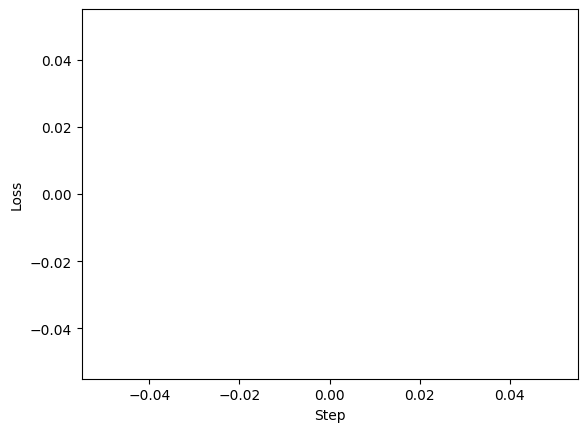

KeyboardInterrupt: 

In [ ]:
trainer = Trainer(model=model)

In [ ]:
model = trainer.train(dataloader_train, num_epoch=2, make_plot=False)

In [ ]:
trainer.evaluate(dataloader_val, make_plot=False)


In [ ]:
trainer.test(dataloader_test, make_plot = False)